# 01 - Overview de seguridad por repositorio

Este notebook carga `data/results/analysis.json` y presenta una vista general de componentes, vulnerabilidades, issues de CodeQL y hallazgos CI/CD por repositorio.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def find_project_root(start: Path | None = None) -> Path:
    start = start or Path.cwd()
    for candidate in [start, *start.parents]:
        if (candidate / 'data' / 'results' / 'analysis.json').exists():
            return candidate
    return Path.cwd()


root = find_project_root()
analysis_path = root / 'data' / 'results' / 'analysis.json'

if not analysis_path.exists():
    raise FileNotFoundError(f'No se encontró analysis.json en: {analysis_path}')

with analysis_path.open('r', encoding='utf-8') as f:
    analysis = json.load(f)

repos = analysis.get('repositories', [])
metadata = analysis.get('metadata', {})

metadata


{'generated_at': '2026-05-03T20:50:18.032543+00:00',
 'repos_analyzed': 6,
 'data_sources': ['sbom', 'grype', 'codeql', 'cicd']}

In [2]:
rows = []
for repo in repos:
    rows.append({
        'name': repo.get('name', 'unknown'),
        'components': repo.get('sbom', {}).get('total_components', 0),
        'vulnerabilities': repo.get('vulnerabilities', {}).get('total', 0),
        'codeql_issues': repo.get('codeql', {}).get('total_issues', 0),
        'cicd_findings': repo.get('cicd', {}).get('total_findings', 0),
        'risk_score': repo.get('metrics', {}).get('risk_score', 0.0),
        'vulnerability_density': repo.get('metrics', {}).get('vulnerability_density', 0.0),
    })

df_repos = pd.DataFrame(rows).sort_values('risk_score', ascending=False).reset_index(drop=True)
df_repos


,name,components,vulnerabilities,codeql_issues,cicd_findings,risk_score,vulnerability_density
0,deepagents,2276,10,11,2,23.11,0.439367
1,docs,502,5,0,0,9.00,0.996016
2,streaming-cookbook,899,4,0,0,8.00,0.444939
3,langsmith-java,14,2,0,0,6.00,14.285714
4,langchain,2330,1,13,2,1.13,0.042918
5,langsmith-go,31,0,0,0,0.00,0.000000


## Gráficos de distribución por repositorio

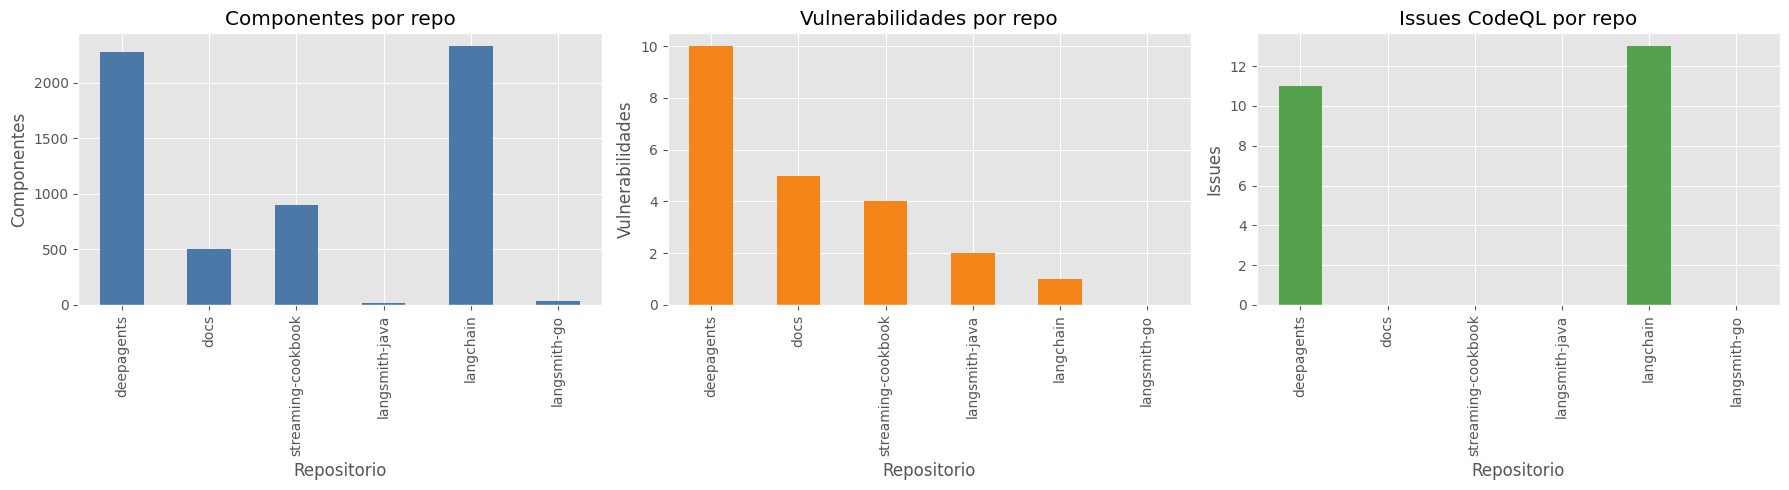

In [3]:
plt.style.use('ggplot')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df_repos.plot.bar(x='name', y='components', ax=axes[0], legend=False, color='#4C78A8')
axes[0].set_title('Componentes por repo')
axes[0].set_xlabel('Repositorio')
axes[0].set_ylabel('Componentes')

df_repos.plot.bar(x='name', y='vulnerabilities', ax=axes[1], legend=False, color='#F58518')
axes[1].set_title('Vulnerabilidades por repo')
axes[1].set_xlabel('Repositorio')
axes[1].set_ylabel('Vulnerabilidades')

df_repos.plot.bar(x='name', y='codeql_issues', ax=axes[2], legend=False, color='#54A24B')
axes[2].set_title('Issues CodeQL por repo')
axes[2].set_xlabel('Repositorio')
axes[2].set_ylabel('Issues')

plt.tight_layout()
plt.show()


## Interpretación breve

- La tabla permite comparar rápidamente exposición técnica (componentes) con hallazgos de seguridad.
- `risk_score` y `vulnerability_density` ayudan a priorizar repos con mayor presión de remediación.
- Si un repo no trae CodeQL o CI/CD findings, los campos se mantienen en `0` para no romper el flujo analítico.

In [4]:
severity_order = ['Critical', 'High', 'Medium', 'Low', 'Unknown']

def _safe_int(value):
    try:
        return int(value)
    except (TypeError, ValueError):
        return 0

severity_totals = {level: 0 for level in severity_order}
for repo in repos:
    by_sev = repo.get('vulnerabilities', {}).get('by_severity', {}) or {}
    for level in severity_order:
        severity_totals[level] += _safe_int(by_sev.get(level, 0))

top_repo = 'N/A'
top_risk = 0.0
if not df_repos.empty:
    top_repo = str(df_repos.iloc[0].get('name', 'N/A'))
    top_risk = float(df_repos.iloc[0].get('risk_score', 0.0) or 0.0)

most_common_severity = max(severity_totals, key=severity_totals.get) if severity_totals else 'Unknown'
total_high_critical = severity_totals.get('High', 0) + severity_totals.get('Critical', 0)
total_cicd = _safe_int(df_repos['cicd_findings'].sum()) if 'cicd_findings' in df_repos else 0

print('Conclusiones dinámicas (overview):')
print(f'- Repo con mayor risk_score: {top_repo} ({top_risk:.2f})')
print(f'- Severidad más común: {most_common_severity}')
print(f'- Total High/Critical: {total_high_critical}')
print(f'- Total hallazgos CI/CD: {total_cicd}')


Conclusiones dinámicas (overview):
- Repo con mayor risk_score: deepagents (23.11)
- Severidad más común: Critical
- Total High/Critical: 0
- Total hallazgos CI/CD: 4
